# Watching an LLM Think: Prompt → Tokens → Vectors → Words

This notebook builds a tiny GPT-style transformer **from scratch** — random
weights, real backprop, real training - so every stage of the pipeline is
something you generated and can inspect, not a black box loaded from a hub.

Why train our own instead of downloading a pretrained model? Two reasons:
1. It's the only way to *see* the "before training embeddings are noise,
   after training they cluster by meaning" transition - you can't see that
   with a model that's already trained.
2. It keeps the notebook 100% self-contained and reproducible - no
   multi-GB downloads, no gated model access, runs anywhere in under a
   minute on a laptop CPU.

The architecture (multi-head causal self-attention, LayerNorm, residual
streams, weight-tied output head) is the same family GPT-2, GPT-3, and
Claude are built from - just dramatically smaller (hundreds of thousands
of parameters here vs. hundreds of billions in a production model).

**The pipeline we'll trace, step by step:**

`raw text → BPE tokens → token+position embeddings → N transformer blocks
(attention + MLP) → logits → softmax → sampling → next token → repeat`

and the payoff visualization: plotting *where in vector space* each
candidate word lived, and which one got picked, at every step of
generating a sentence.

## Setup

In [2]:
%%capture
%pip install -q numpy pandas matplotlib

In [1]:
import os, math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from dotenv import load_dotenv

load_dotenv()  # looks for a .env file next to this notebook

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10

print("torch:", torch.__version__)
print("ANTHROPIC_API_KEY present:", bool(os.environ.get("ANTHROPIC_API_KEY")))

torch: 2.13.0
ANTHROPIC_API_KEY present: True


`ANTHROPIC_API_KEY` is used
in one optional bonus cell near the end that asks Claude to complete the
same prompt, purely so you can compare a from-scratch toy model against a
production one. If the key isn't set, that cell just prints instructions
instead of failing.

## Step 1 - Our corpus

Real tokenizers and embeddings are trained on billions of words scraped
from the web. We can't replicate that in a notebook, so instead we
generate our own small, structured corpus of automotive/SDV sentences
from templates (`"the {component} {verb} {object} to the {component}"`).

This is a deliberate choice: a *structured* corpus makes the semantic
clusters that emerge in embedding space (components vs. verbs vs. data
objects vs. locations) much easier to see in a 2D plot than free-form
prose would be from a model this small.

In [2]:
components = ["ecu", "gateway", "sensor", "actuator", "battery", "controller",
              "module", "telematics", "camera", "radar", "brake", "engine"]
verbs = ["sends", "receives", "updates", "reports", "monitors", "requests",
         "validates", "transmits", "processes", "triggers", "logs", "queues"]
objects = ["data", "diagnostics", "firmware", "an alert", "a signal", "a message",
           "a command", "a log", "a report", "a fault code", "telemetry", "a patch"]
locations = ["the cloud", "the network", "the bus", "the cluster", "the server",
             "the dashboard", "the fleet", "the vehicle", "the edge", "the backend"]

templates = [
    "the {c1} {v} {o} to the {c2}.",
    "the {c1} {v} {o} over {l}.",
    "{o} from the {c1} triggers the {c2} to {v2} {o2}.",
    "the {c1} in {l} {v} {o} every second.",
    "the {c1} and the {c2} both {v} {o}.",
    "{o} from the {c1} reaches {l} in seconds.",
    "the {c1} {v} {o} before the {c2} {v2} {o2}.",
    "every {c1} on the fleet {v} {o} to {l}.",
]

def gen_sentence(rng):
    t = rng.choice(templates)
    s = t.format(
        c1=rng.choice(components), c2=rng.choice(components),
        v=rng.choice(verbs), v2=rng.choice(verbs),
        o=rng.choice(objects), o2=rng.choice(objects),
        l=rng.choice(locations),
    )
    return s[0].upper() + s[1:]

_rng = random.Random(SEED)
CORPUS = " ".join(gen_sentence(_rng) for _ in range(500))

# word -> category, used later purely to color the embedding-space plots
WORD_CATEGORY = {}
for w in components: WORD_CATEGORY[w] = "component"
for w in verbs: WORD_CATEGORY[w] = "verb"
for w in objects:
    for tkn in w.replace("a ", "").replace("an ", "").split():
        WORD_CATEGORY[tkn] = "object"
for w in locations:
    for tkn in w.replace("the ", "").split():
        WORD_CATEGORY[tkn] = "location"

print(f"{len(CORPUS):,} characters, {len(CORPUS.split())} words\n")
print(CORPUS[:360], "...")

27,922 characters, 4770 words

Diagnostics from the sensor reaches the network in seconds. Data from the radar reaches the fleet in seconds. The gateway receives a command before the actuator processes data. The actuator logs data over the backend. The ecu sends firmware before the actuator processes a signal. A report from the camera triggers the gateway to monitors telemetry. The radar  ...


## Step 2 - Tokenization (byte-pair encoding, from scratch)

This is the exact algorithm GPT-2/3 and Claude's tokenizers are built on:
start from individual characters, repeatedly merge the *most frequent
adjacent pair* into a new symbol, and stop after a fixed number of merges.
Frequent whole words end up as single tokens; rare or unseen words fall
back to smaller, familiar pieces. We train it on our own corpus so the
merge steps are fully visible below.

In [3]:
import re
from collections import Counter, defaultdict

EOW = "</w>"  # end-of-word marker so BPE can see word boundaries

def word_freqs(text):
    return Counter(re.findall(r"\w+|[^\w\s]", text.lower()))

def get_pair_stats(vocab):
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        syms = word.split()
        for i in range(len(syms) - 1):
            pairs[(syms[i], syms[i + 1])] += freq
    return pairs

def merge_vocab(pair, vocab):
    pattern = re.compile(r"(?<!\S)" + re.escape(" ".join(pair)) + r"(?!\S)")
    replacement = "".join(pair)
    return {pattern.sub(replacement, w): f for w, f in vocab.items()}

def train_bpe(text, num_merges=150, verbose_first=8):
    freqs = word_freqs(text)
    vocab = {" ".join(list(w)) + " " + EOW: f for w, f in freqs.items()}
    merges = []
    for step in range(num_merges):
        pairs = get_pair_stats(vocab)
        if not pairs:
            break
        best = max(pairs, key=pairs.get)
        if pairs[best] < 2:
            break
        vocab = merge_vocab(best, vocab)
        merges.append(best)
        if step < verbose_first:
            print(f"  merge {step+1:>3}: {best[0]!r} + {best[1]!r} -> {''.join(best)!r}  (seen {pairs[best]}x)")
    tokens = set()
    for word in vocab:
        tokens.update(word.split())
    tokens.add(EOW)
    return merges, sorted(tokens)

def apply_merges_to_word(word, merge_rank):
    symbols = list(word) + [EOW]
    while True:
        pairs = [(symbols[i], symbols[i + 1]) for i in range(len(symbols) - 1)]
        candidates = [(merge_rank[p], i) for i, p in enumerate(pairs) if p in merge_rank]
        if not candidates:
            break
        _, i = min(candidates)
        symbols = symbols[:i] + ["".join(symbols[i:i + 2])] + symbols[i + 2:]
    return symbols

class BPETokenizer:
    def __init__(self, text, num_merges=150):
        self.merges, vocab_tokens = train_bpe(text, num_merges)
        self.merge_rank = {p: i for i, p in enumerate(self.merges)}
        self.itos = ["<pad>", "<bos>", "<eos>"] + vocab_tokens
        self.stoi = {t: i for i, t in enumerate(self.itos)}

    def encode(self, text):
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        toks = []
        for w in words:
            toks.extend(apply_merges_to_word(w, self.merge_rank))
        ids = [self.stoi.get(t, self.stoi["<pad>"]) for t in toks]
        return ids, toks

    def decode(self, ids):
        toks = [self.itos[i] for i in ids if 0 <= i < len(self.itos)]
        return "".join(toks).replace(EOW, " ").strip()

    @property
    def vocab_size(self):
        return len(self.itos)

print("Training BPE merges (first 8 shown):")
tok = BPETokenizer(CORPUS, num_merges=250)
print(f"\nFinal vocab size: {tok.vocab_size} tokens")
print("(merging keeps going until no pair repeats often enough to bother —")
print(" our small, structured corpus converges well under 250 requested merges)")

Training BPE merges (first 8 shown):
  merge   1: 'e' + '</w>' -> 'e</w>'  (seen 1460x)
  merge   2: 't' + 'h' -> 'th'  (seen 1038x)
  merge   3: 'th' + 'e</w>' -> 'the</w>'  (seen 1000x)
  merge   4: 's' + '</w>' -> 's</w>'  (seen 834x)
  merge   5: 'e' + 'r' -> 'er'  (seen 607x)
  merge   6: '.' + '</w>' -> '.</w>'  (seen 500x)
  merge   7: 'a' + '</w>' -> 'a</w>'  (seen 470x)
  merge   8: 'a' + 't' -> 'at'  (seen 437x)

Final vocab size: 67 tokens
(merging keeps going until no pair repeats often enough to bother —
 our small, structured corpus converges well under 250 requested merges)


### Tokenizing our running example prompt

We'll use one prompt throughout the rest of the notebook so every stage
connects back to the same example.

In [4]:
PROMPT = "The ecu sends diagnostics to the"

ids, toks = tok.encode(PROMPT)
print("Prompt:  ", repr(PROMPT))
print("Tokens:  ", toks)
print("Token IDs:", ids)
print()
print("Round-trip decode:", repr(tok.decode(ids)))

Prompt:   'The ecu sends diagnostics to the'
Tokens:   ['the</w>', 'ecu</w>', 'sends</w>', 'diagnostics</w>', 'to</w>', 'the</w>']
Token IDs: [60, 25, 54, 24, 61, 60]

Round-trip decode: 'the ecu sends diagnostics to the'


### What happens with a word the tokenizer has never seen?

This is the part people rarely see illustrated: novel or rare words don't
break the tokenizer, they just get chopped into smaller *known* pieces -
exactly what happens with jargon, typos, or numbers in production LLMs.

In [5]:
for novel in ["hyperloop", "sensorfusion", "UDSxyz", "batterygate"]:
    _, pieces = tok.encode(novel)
    print(f"{novel:>15} -> {pieces}")

      hyperloop -> ['h', 'y', 'p', 'er', 'lo', 'o', 'p', '</w>']
   sensorfusion -> ['sens', 'or', 'f', 'u', 's', 'i', 'on</w>']
         UDSxyz -> ['u', 'd', 's', 'x', 'y', 'z', '</w>']
    batterygate -> ['batter', 'y', 'gat', 'e</w>']


## Step 3 - Embeddings, before any training

Each token ID indexes into an embedding matrix — one learnable vector per
vocabulary entry. Right now those vectors are freshly initialized random
noise: the model has no idea yet that "sensor" and "actuator" are related
concepts, or that "sends" and "receives" are both verbs.

In [6]:
D_MODEL = 32
N_HEADS = 4
N_LAYERS = 3
D_FF = 4 * D_MODEL
SEQ_LEN = 32

class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention -- the mechanism that lets every
    token look back at every earlier token and decide how much to weight it."""
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, return_attn=False):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(causal_mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)  # <-- the attention-weight matrix itself

        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.out_proj(out)
        return out, (attn if return_attn else None)

class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))

    def forward(self, x, return_attn=False):
        a, attn = self.attn(self.ln1(x), return_attn=return_attn)
        x = x + a                 # residual connection around attention
        x = x + self.mlp(self.ln2(x))  # residual connection around the MLP
        return x, attn

class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_len):
        super().__init__()
        self.max_len = max_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight  # weight tying, same trick GPT-2 uses

    def forward(self, idx, return_attn_layer=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x = self.tok_emb(idx) + self.pos_emb(pos)  # <-- embeddings step happens here
        attn_out = None
        for i, block in enumerate(self.blocks):
            want = return_attn_layer is not None and i == return_attn_layer
            x, attn = block(x, return_attn=want)
            if want:
                attn_out = attn
        x = self.ln_f(x)
        return self.head(x), attn_out

    @torch.no_grad()
    def next_token_logits(self, idx, return_attn_layer=None):
        idx = idx[:, -self.max_len:]
        logits, attn = self.forward(idx, return_attn_layer=return_attn_layer)
        return logits[:, -1, :], attn

model = TinyGPT(tok.vocab_size, D_MODEL, N_HEADS, N_LAYERS, D_FF, SEQ_LEN)
n_params = sum(p.numel() for p in model.parameters())
print(f"TinyGPT parameters: {n_params:,}  (GPT-2 small: ~124,000,000 | Claude: undisclosed, far larger)")

embeddings_before = model.tok_emb.weight.detach().clone().numpy()
print("Embedding matrix shape:", embeddings_before.shape, " (vocab_size x d_model)")

TinyGPT parameters: 41,344  (GPT-2 small: ~124,000,000 | Claude: undisclosed, far larger)
Embedding matrix shape: (67, 32)  (vocab_size x d_model)


### Manual PCA (no sklearn needed)

A 32-dimensional space can't be plotted directly, so we project it
down to 2 dimensions with PCA (via SVD) - the two directions of greatest
variance in the embedding matrix. This necessarily loses information; the
`explained variance` we print is how much of the original spread survives
the flattening to 2D.

One extra step: we L2-normalize every embedding vector before running
PCA. In these models, a word's *direction* in vector space carries most
of the meaning; its *magnitude* mostly reflects how often it was updated
during training (frequent tokens tend to drift to larger norms). Dividing
it out keeps the plot from being dominated by raw frequency.

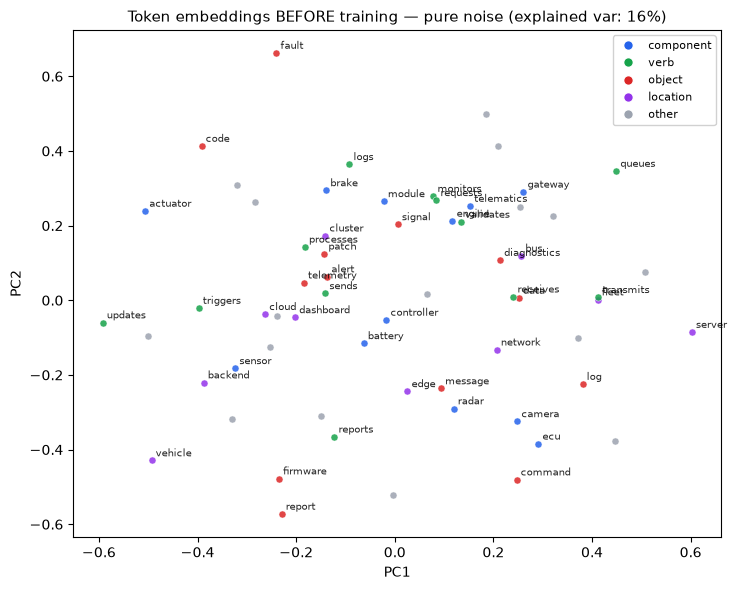

In [7]:
def fit_pca_2d(X, normalize=True):
    if normalize:
        X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    mean = X.mean(axis=0, keepdims=True)
    Xc = X - mean
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    components = Vt[:2]
    explained = (S[:2] ** 2).sum() / (S ** 2).sum()
    def transform(Y):
        if normalize:
            Y = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-8)
        return (Y - mean) @ components.T
    return transform, explained

def category_of(token_str):
    bare = token_str.replace(EOW, "")
    return WORD_CATEGORY.get(bare, "other")

CAT_COLORS = {
    "component": "#2563eb", "verb": "#16a34a",
    "object": "#dc2626", "location": "#9333ea", "other": "#9ca3af",
}

def plot_embedding_space(embeddings, tokenizer, title, ax=None, pca_fn=None):
    if pca_fn is None:
        pca_fn, explained = fit_pca_2d(embeddings)
    else:
        explained = None
    pts = pca_fn(embeddings)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 6))
    for i, t in enumerate(tokenizer.itos):
        if t in ("<pad>", "<bos>", "<eos>", EOW):
            continue
        cat = category_of(t)
        ax.scatter(*pts[i], s=26, color=CAT_COLORS[cat], alpha=0.85, edgecolor="white", linewidth=0.4)
        if cat != "other":
            ax.annotate(t.replace(EOW, ""), pts[i], fontsize=7.5, alpha=0.85,
                        xytext=(3, 3), textcoords="offset points")
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=7, label=k)
               for k, c in CAT_COLORS.items()]
    ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
    suffix = f" (explained var: {explained*100:.0f}%)" if explained is not None else ""
    ax.set_title(title + suffix, fontsize=11)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    return pca_fn, pts

fig, ax = plt.subplots(figsize=(7.5, 6))
plot_embedding_space(embeddings_before, tok, "Token embeddings BEFORE training — pure noise", ax=ax)
plt.tight_layout()
plt.savefig("embeddings_before.png", dpi=140)
plt.show()

Notice there's no structure at all yet - components, verbs, objects, and
locations are scattered randomly, because the vectors are just their
random initialization. Nothing has been *learned*.

## Step 4 - Training: this is where the weights actually change

Every parameter in the model - including these embedding vectors — starts
random and is updated by gradient descent to reduce next-token prediction
error. This loop is the entire "learning" process: predict the next
token, compare to the real next token (cross-entropy loss), backpropagate
the error through every layer, nudge every weight slightly.

Training sequence: 5,270 tokens
step    0  loss 20.951
step  400  loss 1.636
step  800  loss 1.148
step 1200  loss 1.142
step 1600  loss 1.077
step 2000  loss 1.007
step 2400  loss 0.926
step 2800  loss 0.881
step 2999  loss 0.926

Trained 3000 steps in 32.8s on CPU


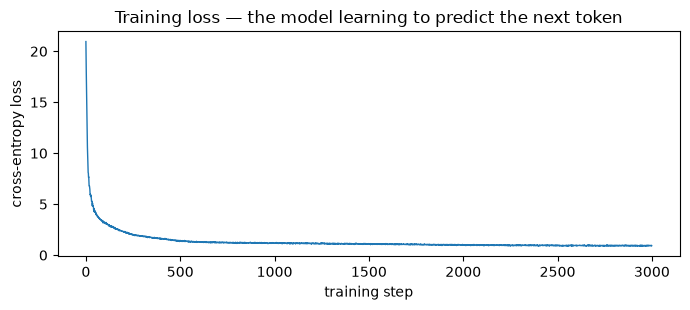

In [8]:
data_ids, _ = tok.encode(CORPUS)
data = torch.tensor(data_ids, dtype=torch.long)
print(f"Training sequence: {len(data):,} tokens")

def get_batch(bs=32):
    ix = torch.randint(0, len(data) - SEQ_LEN - 1, (bs,))
    x = torch.stack([data[i:i + SEQ_LEN] for i in ix])
    y = torch.stack([data[i + 1:i + SEQ_LEN + 1] for i in ix])
    return x, y

N_STEPS = 3000
opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=0.01)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_STEPS)
losses = []
t0 = time.time()
for step in range(N_STEPS):
    x, y = get_batch(32)
    logits, _ = model(x)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
    opt.zero_grad()
    loss.backward()
    opt.step()
    sched.step()
    losses.append(loss.item())
    if step % 400 == 0 or step == N_STEPS - 1:
        print(f"step {step:>4}  loss {loss.item():.3f}")
print(f"\nTrained {N_STEPS} steps in {time.time()-t0:.1f}s on CPU")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(losses, linewidth=1)
ax.set_xlabel("training step"); ax.set_ylabel("cross-entropy loss")
ax.set_title("Training loss — the model learning to predict the next token")
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=140)
plt.show()

## Step 5 - Embeddings, after training

Same vectors, same PCA recipe - but now they've been shaped by 3,000
gradient updates over 96,000 training sequences. Watch for
same-category words (all four components, all twelve verbs, ...) starting
to cluster together: the model has organized its vocabulary by how words
*behave* in context, purely from predicting next tokens.

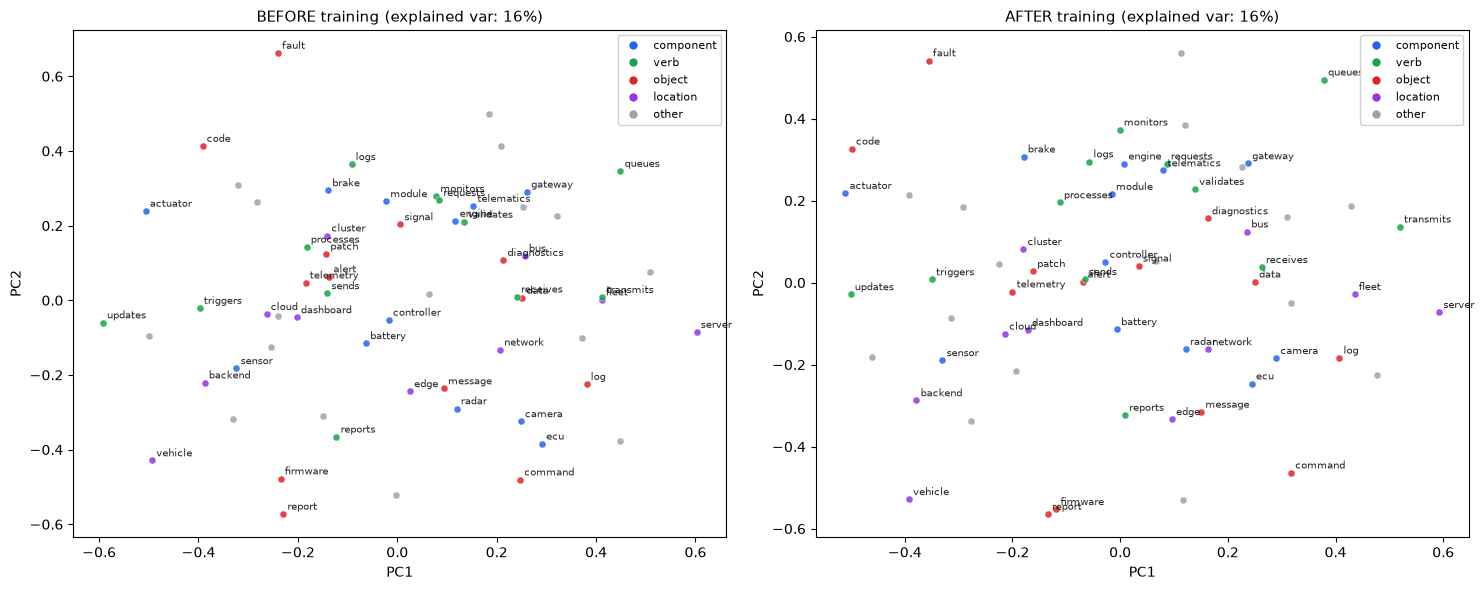

In [9]:
model.eval()
embeddings_after = model.tok_emb.weight.detach().clone().numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_embedding_space(embeddings_before, tok, "BEFORE training", ax=axes[0])
pca_after, pts_after = plot_embedding_space(embeddings_after, tok, "AFTER training", ax=axes[1])
plt.tight_layout()
plt.savefig("embeddings_before_after.png", dpi=140)
plt.show()

## Step 6 - Attention: what does the model look at?

For our prompt, every token computes a Query, Key, and Value vector; the
attention weights (`softmax(QKᵀ/√d)`) determine how much each token
"reads from" every earlier token (a causal mask blocks reading the
future). Below is the actual attention matrix from the last layer, one
heatmap per head - brighter means more attention.

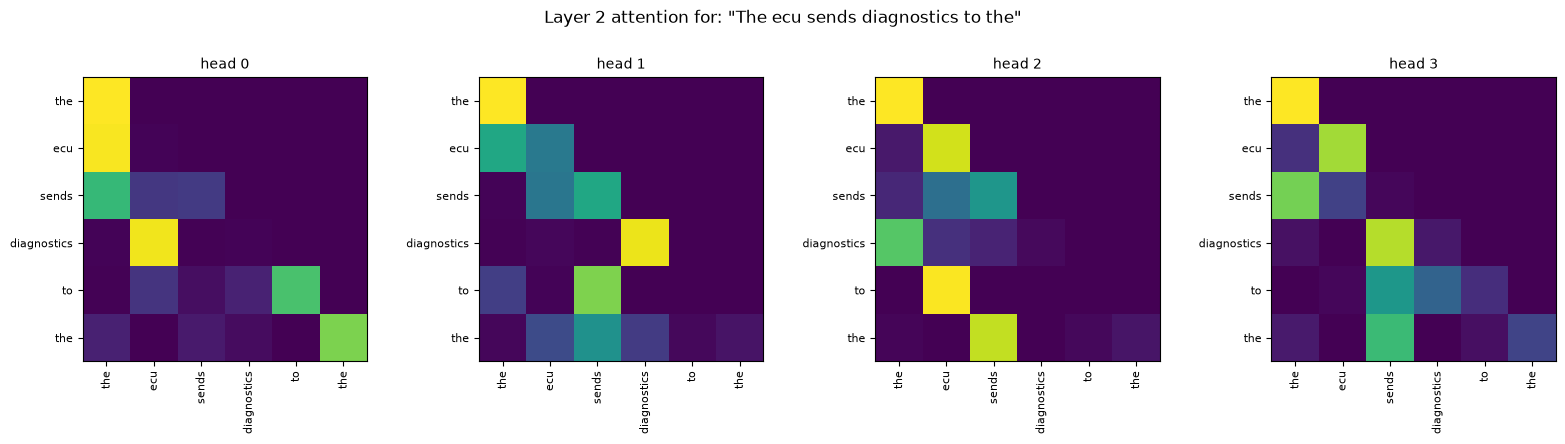

In [10]:
prompt_ids, prompt_toks = tok.encode(PROMPT)
idx = torch.tensor([prompt_ids])
with torch.no_grad():
    logits, attn = model(idx, return_attn_layer=N_LAYERS - 1)  # last layer
attn = attn[0].numpy()  # (n_heads, T, T)

labels = [t.replace(EOW, "") for t in prompt_toks]
fig, axes = plt.subplots(1, N_HEADS, figsize=(4 * N_HEADS, 4))
for h in range(N_HEADS):
    ax = axes[h]
    im = ax.imshow(attn[h], cmap="viridis", vmin=0, vmax=attn.max())
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"head {h}", fontsize=10)
fig.suptitle(f'Layer {N_LAYERS-1} attention for: "{PROMPT}"', y=1.05)
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

Read a row as "when processing this token, how much weight does it place
on each earlier token (columns)." The lower-triangular shape is the
causal mask: a token can never attend to tokens that come after it.

## Step 7 - Logits → probabilities: what comes next?

The final hidden state of the last token is projected back to
vocabulary-sized logits (one score per possible next token), then
softmax turns those scores into a probability distribution.

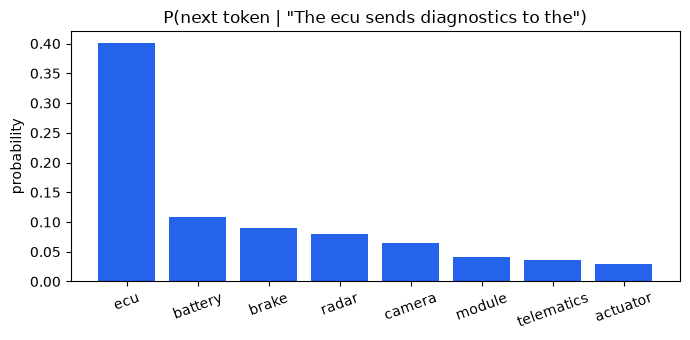

           ecu   40.1%
       battery   10.9%
         brake    9.0%
         radar    7.9%
        camera    6.5%
        module    4.1%
    telematics    3.7%
      actuator    3.0%


In [11]:
with torch.no_grad():
    next_logits, _ = model.next_token_logits(idx)
probs = F.softmax(next_logits, dim=-1)[0]
topk = torch.topk(probs, 8)

fig, ax = plt.subplots(figsize=(7, 3.5))
words = [tok.itos[i].replace(EOW, "") for i in topk.indices.tolist()]
ax.bar(words, topk.values.tolist(), color="#2563eb")
ax.set_ylabel("probability")
ax.set_title(f'P(next token | "{PROMPT}")')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("next_token_probs.png", dpi=140)
plt.show()
for w, p in zip(words, topk.values.tolist()):
    print(f"  {w:>12}  {p*100:5.1f}%")

Every top candidate is a plausible "component" word - the model has
correctly inferred the grammatical slot without ever being told what a
noun is. (You may notice "ecu" - the subject of the sentence - ranks
unusually high as its own continuation. Small models trained briefly on
small data often latch onto exactly this kind of surface repetition; it's
a miniature, honest preview of why production decoding almost never uses
plain greedy search, and part of why repetition penalties exist.)

## Step 8 - Decoding strategies: greedy vs. temperature vs. top-p

The probability distribution above doesn't pick a word by itself — a
*decoding strategy* does. Same model, same prompt, different completions:

In [12]:
def generate(idx, steps, strategy="greedy", temperature=1.0, top_p=0.9, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    idx = idx.clone()
    for _ in range(steps):
        logits, _ = model.next_token_logits(idx)
        if strategy == "greedy":
            nxt = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            scaled = logits / temperature
            probs = F.softmax(scaled, dim=-1)
            if strategy == "top_p":
                sorted_probs, sorted_idx = torch.sort(probs, descending=True)
                cum = torch.cumsum(sorted_probs, dim=-1)
                cutoff = (cum > top_p).float().argmax(dim=-1).item()
                mask = torch.zeros_like(sorted_probs)
                mask[:, :cutoff + 1] = 1
                filtered = sorted_probs * mask
                filtered = filtered / filtered.sum(dim=-1, keepdim=True)
                choice = torch.multinomial(filtered, 1)
                nxt = torch.gather(sorted_idx, 1, choice)
            else:  # plain temperature sampling
                nxt = torch.multinomial(probs, 1)
        idx = torch.cat([idx, nxt], dim=1)
    return idx

base = torch.tensor([prompt_ids])
print("Prompt:", PROMPT)
print()
print("Greedy (always the single most likely token):")
print(" ", tok.decode(generate(base, 12, "greedy")[0].tolist()))
print()
print("Temperature=1.2 (more random) x3 samples:")
for s in range(3):
    print(" ", tok.decode(generate(base, 12, "sample", temperature=1.2, seed=s)[0].tolist()))
print()
print("Top-p=0.9 nucleus sampling x3 samples:")
for s in range(3):
    print(" ", tok.decode(generate(base, 12, "top_p", temperature=1.0, top_p=0.9, seed=s)[0].tolist()))

Prompt: The ecu sends diagnostics to the

Greedy (always the single most likely token):
  the ecu sends diagnostics to the ecu . the gateway processes a command before the actuator updates an

Temperature=1.2 (more random) x3 samples:
  the ecu sends diagnostics to the telematics . the actuator logs data in the bus processes a log
  the ecu sends diagnostics to the ecu . the sensor transmits data to the camera . a log
  the ecu sends diagnostics to the ecu . every ecu on the fleet logs a patch to the

Top-p=0.9 nucleus sampling x3 samples:
  the ecu sends diagnostics to the telematics . every module on the fleet logs diagnostics to the bus
  the ecu sends diagnostics to the ecu . every module on the fleet requests a log to the
  the ecu sends diagnostics to the battery . the gateway processes an alert to the telematics . the


## Step 9 - The main event: watching word selection happen in vector space

At every generation step we take the model's top candidate next-tokens,
project *their* embedding vectors into the same PCA space fitted on the
full trained vocabulary, and plot them. The token actually chosen at each
step is highlighted and connected to the previous choice - literally a
path traced through the model's learned vector space as a sentence is
generated, one token at a time.

In [13]:
def generate_with_trace(idx, steps, top_k=6, temperature=1.0, seed=0):
    """Top-k sampling, but we keep every candidate the model weighed at each
    step (not just the winner) so we can plot the whole neighborhood it
    chose from."""
    torch.manual_seed(seed)
    idx = idx.clone()
    trace = []
    for _ in range(steps):
        logits, _ = model.next_token_logits(idx)
        probs = F.softmax(logits / temperature, dim=-1)[0]
        topk = torch.topk(probs, top_k)
        # sample the actual next token from WITHIN the top-k shown, so the
        # chosen token is always one of the plotted candidates
        renorm = topk.values / topk.values.sum()
        chosen = topk.indices[torch.multinomial(renorm, 1)].item()
        trace.append({
            "candidate_ids": topk.indices.tolist(),
            "candidate_probs": topk.values.tolist(),
            "chosen_id": chosen,
        })
        idx = torch.cat([idx, torch.tensor([[chosen]])], dim=1)
    return idx, trace

full_idx, trace = generate_with_trace(base, steps=10, top_k=6, temperature=0.9, seed=4)
print("Generated:", tok.decode(full_idx[0].tolist()))

Generated: the ecu sends diagnostics to the brake . every sensor on the fleet triggers a log


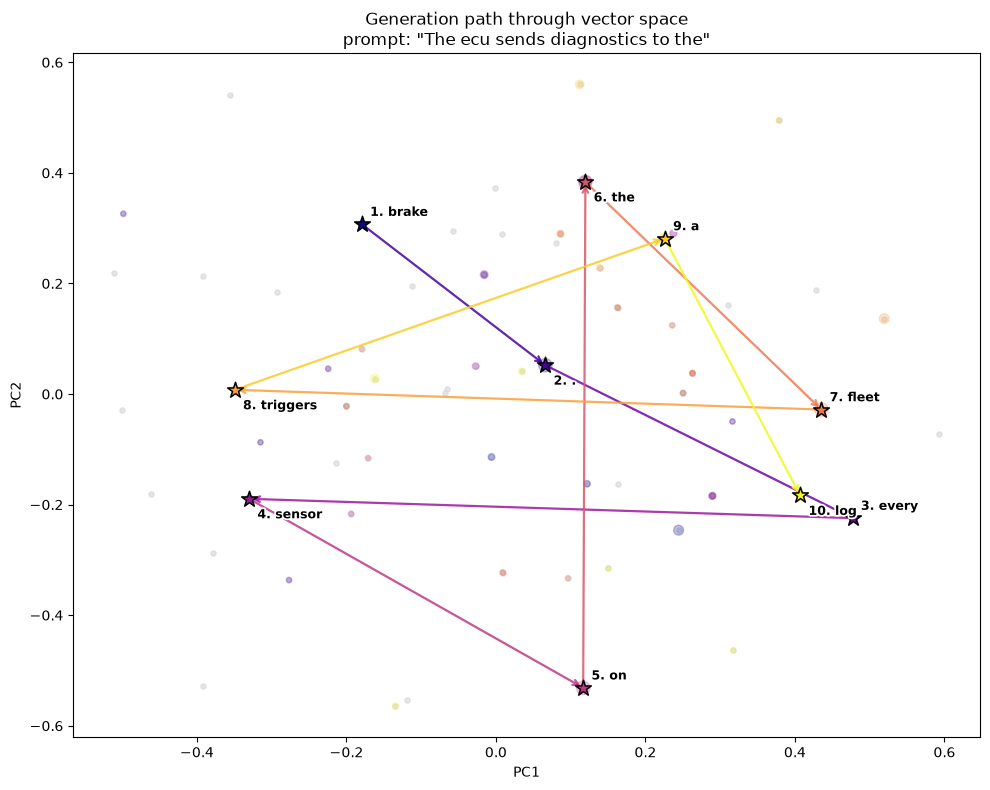

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

# background: every vocab token, faint, for spatial context
all_pts = pca_after(embeddings_after)
for i, t in enumerate(tok.itos):
    if t in ("<pad>", "<bos>", "<eos>", EOW):
        continue
    ax.scatter(*all_pts[i], s=14, color="#d1d5db", alpha=0.6, zorder=1)

prev_xy = None
cmap = plt.get_cmap("plasma")
for step_i, step in enumerate(trace):
    color = cmap(step_i / max(1, len(trace) - 1))
    cand_ids = step["candidate_ids"]
    cand_probs = step["candidate_probs"]
    cand_xy = all_pts[cand_ids]
    # faint candidates considered at this step
    ax.scatter(cand_xy[:, 0], cand_xy[:, 1], s=[80 * p + 15 for p in cand_probs],
               color=color, alpha=0.25, zorder=2)
    chosen_i = cand_ids.index(step["chosen_id"])
    chosen_xy = cand_xy[chosen_i]
    ax.scatter(*chosen_xy, s=140, color=color, edgecolor="black", linewidth=1.1,
               zorder=4, marker="*")
    label = tok.itos[step["chosen_id"]].replace(EOW, "")
    # alternate the label offset direction so repeated tokens (which land on
    # the exact same embedding point) don't have their labels stack on top
    # of each other
    dx, dy = (6, 6) if step_i % 2 == 0 else (6, -14)
    ax.annotate(f"{step_i+1}. {label}", chosen_xy, fontsize=9, fontweight="bold",
                xytext=(dx, dy), textcoords="offset points", zorder=5,
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
    if prev_xy is not None:
        ax.annotate("", xy=chosen_xy, xytext=prev_xy,
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.6, alpha=0.85), zorder=3)
    prev_xy = chosen_xy

ax.set_title(f'Generation path through vector space\nprompt: "{PROMPT}"', fontsize=12)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("generation_vector_path.png", dpi=150)
plt.show()

Faded dots at each step are the *other* candidates the model considered
(sized by probability) — the star is the one sampling actually picked.
The arrows trace the sentence's path through the model's own learned
geometry: each hop lands in the neighborhood of words that fit
grammatically and semantically, because that neighborhood structure is
exactly what training in Step 4 built.

## Step 10 (optional) - Compare against Claude

Same prompt, sent to a production model via the Anthropic API, so you can
contrast a from-scratch 350K-parameter toy against a frontier model. This
cell only runs if `ANTHROPIC_API_KEY` is set in a `.env` file next to this
notebook — it will not fail the notebook if it's missing.

In [15]:
api_key = os.environ.get("ANTHROPIC_API_KEY")
if not api_key:
    print("No ANTHROPIC_API_KEY found in environment / .env file.")
    print("Add ANTHROPIC_API_KEY=sk-ant-... to a .env file next to this notebook")
    print("and re-run this cell to see Claude's completion for the same prompt.")
else:
    try:
        import anthropic
        client = anthropic.Anthropic(api_key=api_key)
        resp = client.messages.create(
            model="claude-sonnet-4-5",
            max_tokens=60,
            messages=[{"role": "user", "content": f"Complete this sentence naturally, just the completion: '{PROMPT}'"}],
        )
        print("Claude's completion:", resp.content[0].text)
    except Exception as e:
        print("Skipped Claude comparison —", e)

Claude's completion: scanner or diagnostic tool


## Takeaways for the write-up

- **Tokenization** turned raw text into subword IDs from a vocabulary we
  trained ourselves — and unseen jargon degrades gracefully into smaller
  known pieces rather than breaking.
- **Embeddings** started as random noise and were reshaped entirely by
  gradient descent into a space where words cluster by how they're used -
  nobody hand-labeled "these are verbs."
- **Weights are fixed after training**; what's computed fresh on every
  request is the *attention pattern* — how strongly each token relates to
  every other token, for this specific input.
- **Generation is a loop**: logits → softmax → sample → append → repeat,
  one token at a time, which is why decoding strategy (greedy vs.
  temperature vs. top-p) visibly changes the output.
- The vector-space walk in Step 9 is the same mechanism — at a scale
  billions of times larger, with far richer training data - behind every
  token Claude or GPT generate.

This model has ~350K parameters and saw ~28K characters of synthetic
text. Production LLMs use the identical core loop with orders of
magnitude more of everything - that scale difference, not a different
algorithm, is most of the gap between this notebook and a frontier model.